In [79]:
from pathlib import Path
from met_pipeline.io import load_excel, load_csv, normalize_kab_kota
from met_pipeline.quality import compute_entity_completeness

PROJECT_ROOT = Path.cwd().parent

df = load_excel(
    PROJECT_ROOT / "data" / "raw" / "Data_Komposisi_Sumber_Sampah_SIPSN_KLHK.xlsx",
    header=0,
)

ref_df = load_csv(
    PROJECT_ROOT / "data" / "reference" / "master_kab_reference_final.csv"
)


In [80]:
df["kab_kota_key"] = df["kabupaten/kota"].apply(normalize_kab_kota)
ref_df["kab_kota_key"] = ref_df["kab_kota"].apply(normalize_kab_kota)

In [81]:
merged = ref_df.merge(
    df,
    on="kab_kota_key",
    how="left"
)

In [82]:
df = merged.copy()

In [83]:
df_2023 = df[df["tahun"] == 2023].copy()

df_2023.shape

(392, 13)

In [84]:
df_2023.head()

,provinsi_x,kab_kota,kab_kota_key,tahun,provinsi_y,kabupaten/kota,rumah tangga(ton),perkantoran(ton),pasar(ton),perniagaan(ton),fasilitas publik(ton),kawasan(ton),lain(ton)
1,Aceh,Kab. Aceh Barat,kabupaten_aceh barat,2023.0,Aceh,Kab. Aceh Barat,48.50,5.70,18.00,15.60,3.00,5.0,5.00
4,Aceh,Kab. Aceh Barat Daya,kabupaten_aceh barat daya,2023.0,Aceh,Kab. Aceh Barat Daya,5.00,1.20,6.00,2.00,3.50,3.5,3.00
7,Aceh,Kab. Aceh Besar,kabupaten_aceh besar,2023.0,Aceh,Kab. Aceh Besar,48.20,2.70,19.60,12.10,4.30,7.8,5.30
9,Aceh,Kab. Aceh Jaya,kabupaten_aceh jaya,2023.0,Aceh,Kab. Aceh Jaya,19.21,2.40,13.44,6.72,2.88,2.4,0.96
13,Aceh,Kab. Aceh Selatan,kabupaten_aceh selatan,2023.0,Aceh,Kab. Aceh Selatan,1.10,0.95,6.00,5.65,5.95,0.4,NaN


In [85]:
df_jatim_2023 = df_2023[df_2023["provinsi_x"] == "Jawa Timur"].copy()

df_jatim_2023.shape

(35, 13)

In [87]:
col = "rumah tangga(ton)"

X = df_jatim_2023[[col]].dropna()

X.shape

(26, 1)

In [88]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.03,  # ~3% anomalies
    random_state=42
)

iso.fit(X)

df_jatim_2023.loc[X.index, "anomaly_flag"] = iso.predict(X)

In [89]:
anomalies = df_jatim_2023[df_jatim_2023["anomaly_flag"] == -1]

anomalies[
    ["kabupaten/kota", col]
].sort_values(col, ascending=False)

,kabupaten/kota,rumah tangga(ton)
731,Kota Surabaya,1308.87


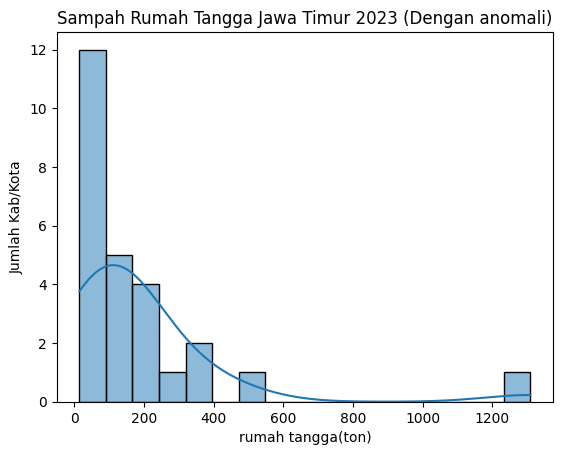

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.histplot(df_jatim_2023[col], kde=True)
plt.ylabel("Jumlah Kab/Kota")
plt.title("Sampah Rumah Tangga Jawa Timur 2023 (Dengan anomali)")
plt.show()

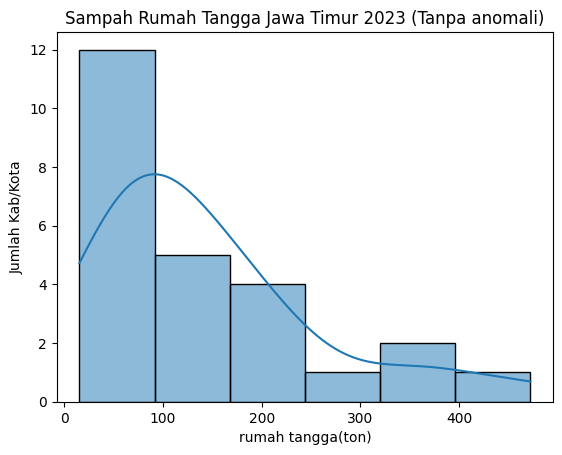

In [102]:
normal_data = df_jatim_2023[df_jatim_2023["anomaly_flag"] == 1][col]

plt.figure()
sns.histplot(normal_data, kde=True)
plt.ylabel("Jumlah Kab/Kota")
plt.title("Sampah Rumah Tangga Jawa Timur 2023 (Tanpa anomali)")
plt.show()

In [48]:
anomalies = df_jatim_2023[df_jatim_2023["anomaly_flag"] == -1]

anomalies[
    ["kabupaten/kota", col]
].sort_values(col, ascending=False)

,kabupaten/kota,rumah tangga(ton)
521,Kota Surabaya,1308.87
500,Kab. Mojokerto,472.17


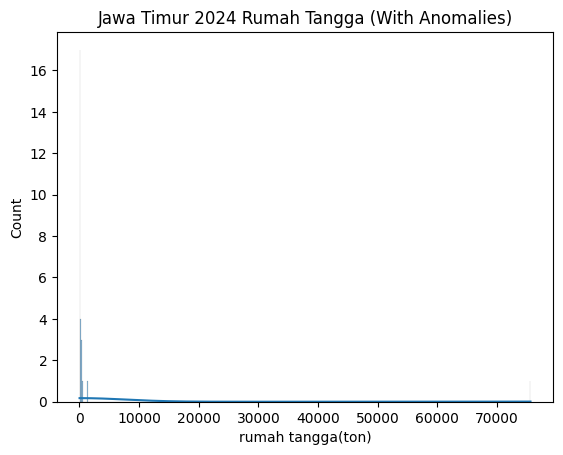

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.histplot(df_jatim_2024[col], kde=True)
plt.title("Jawa Timur 2024 Rumah Tangga (With Anomalies)")
plt.show()

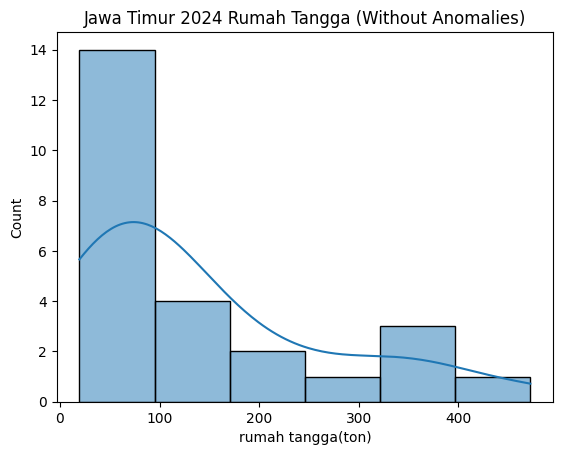

In [51]:
normal_data = df_jatim_2024[df_jatim_2024["anomaly_flag"] == 1][col]

plt.figure()
sns.histplot(normal_data, kde=True)
plt.title("Jawa Timur 2024 Rumah Tangga (Without Anomalies)")
plt.show()

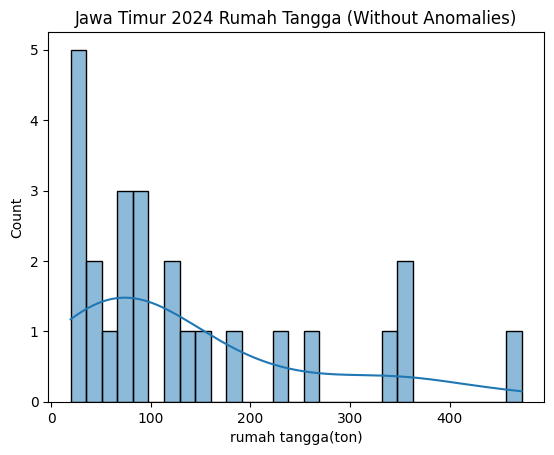

In [ ]:
import numpy as np

bins = np.linspace(normal_data.min(), normal_data.max(), 30)

plt.figure()
sns.histplot(normal_data, bins=bins, kde=True)
plt.title("Jawa Timur 2024 Rumah Tangga (Without Anomalies)")
plt.show()


In [ ]:
#test